# Penguin Species Classification
**Goal:** Predict penguin species (Adelie / Chinstrap / Gentoo) from physical measurements — a **multiclass** classification problem.

**Workflow:**
1. Data Loading & Inspection
2. Exploratory Data Analysis (EDA)
3. Preprocessing
4. Model Comparison (cross-validated)
5. Hyperparameter Tuning
6. Final Evaluation & Feature Importance
7. Conclusions

In [71]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay
)
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

RANDOM_STATE = 42
SPECIES = ['Adelie', 'Chinstrap', 'Gentoo']
PALETTE = {'Adelie': '#4e9af1', 'Chinstrap': '#f1814e', 'Gentoo': '#6abf69'}

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110
print('Imports OK')

Imports OK


## 1. Data Loading & Inspection

In [72]:
df = pd.read_csv('Classic Datasets/penguins.csv')
print(f'Shape: {df.shape}')
df.head()

Shape: (344, 7)


,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,female


In [73]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            344 non-null    object 
 1   island             344 non-null    object 
 2   bill_length_mm     342 non-null    float64
 3   bill_depth_mm      342 non-null    float64
 4   flipper_length_mm  342 non-null    float64
 5   body_mass_g        342 non-null    float64
 6   sex                333 non-null    object 
dtypes: float64(4), object(3)
memory usage: 18.9+ KB


In [74]:
df.describe()

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
count,342.000000,342.000000,342.000000,342.000000
mean,43.921930,17.151170,200.915205,4201.754386
std,5.459584,1.974793,14.061714,801.954536
min,32.100000,13.100000,172.000000,2700.000000
25%,39.225000,15.600000,190.000000,3550.000000
50%,44.450000,17.300000,197.000000,4050.000000
75%,48.500000,18.700000,213.000000,4750.000000
max,59.600000,21.500000,231.000000,6300.000000


In [75]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(1)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
print(missing_df[missing_df['Missing Count'] > 0])

                   Missing Count  Missing %
bill_length_mm                 2        0.6
bill_depth_mm                  2        0.6
flipper_length_mm              2        0.6
body_mass_g                    2        0.6
sex                           11        3.2


**Missing value strategy:**
- Measurements (`bill_length_mm`, `bill_depth_mm`, `flipper_length_mm`, `body_mass_g`) — only 2 rows missing, drop them (imputing physical measurements without knowing species is unreliable)
- `sex` — 11 rows missing, fill with the **mode per species** (male/female ratios differ slightly by species)

In [76]:
print('Species counts:')
print(df['species'].value_counts())
print(f'\nIsland counts:')
print(df['island'].value_counts())

Species counts:
species
Adelie       152
Gentoo       124
Chinstrap     68
Name: count, dtype: int64

Island counts:
island
Biscoe       168
Dream        124
Torgersen     52
Name: count, dtype: int64


## 2. Exploratory Data Analysis (EDA)

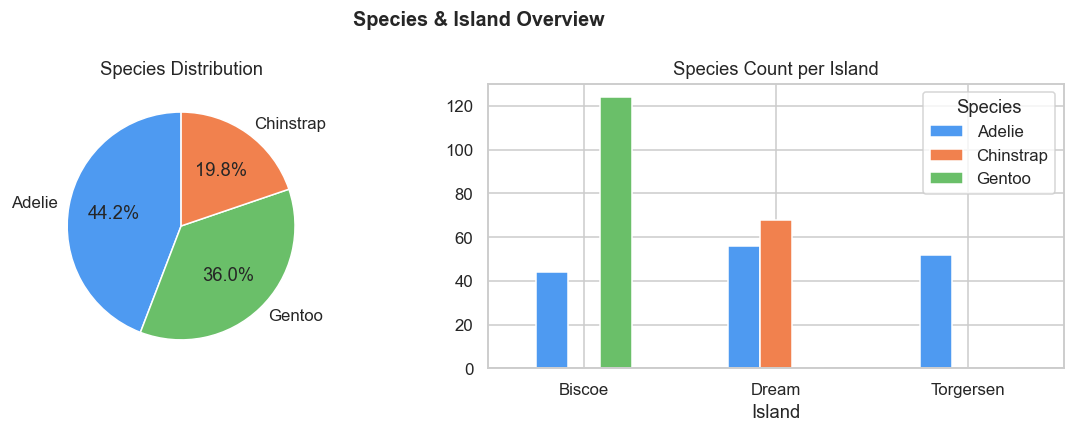

Key: Chinstrap only on Dream, Gentoo mostly on Biscoe, Adelie on all islands.


In [77]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Species distribution
counts = df['species'].value_counts()
axes[0].pie(
    counts, labels=counts.index, autopct='%1.1f%%',
    colors=[PALETTE[s] for s in counts.index], startangle=90
)
axes[0].set_title('Species Distribution')

# Species per island
island_species = df.groupby(['island', 'species']).size().unstack(fill_value=0)
island_species.plot(kind='bar', ax=axes[1],
                    color=[PALETTE[s] for s in island_species.columns],
                    edgecolor='white')
axes[1].set_title('Species Count per Island')
axes[1].set_xlabel('Island')
axes[1].tick_params(axis='x', rotation=0)
axes[1].legend(title='Species')

plt.suptitle('Species & Island Overview', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('Key: Chinstrap only on Dream, Gentoo mostly on Biscoe, Adelie on all islands.')

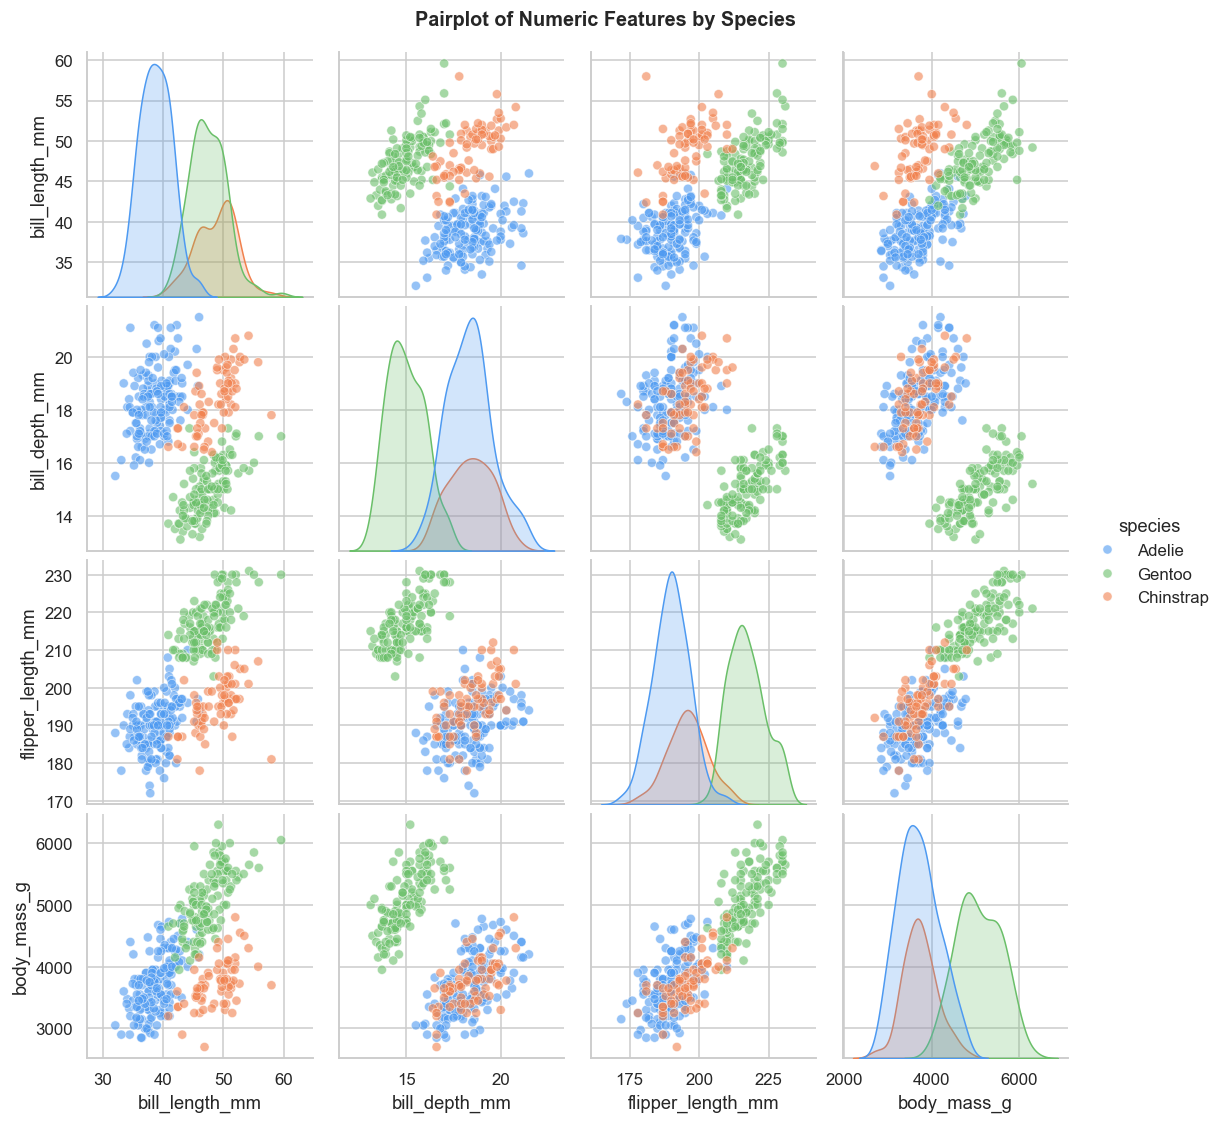

Gentoo are clearly larger (flipper + body mass).
Adelie vs Chinstrap are best separated by bill_length_mm + bill_depth_mm.


In [78]:
# Pairplot — the most informative plot for this dataset
numeric_features = ['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']
df_plot = df.dropna(subset=numeric_features)

pair_grid = sns.pairplot(
    df_plot, vars=numeric_features,
    hue='species', palette=PALETTE,
    diag_kind='kde', plot_kws={'alpha': 0.6}
)
pair_grid.fig.suptitle('Pairplot of Numeric Features by Species', y=1.02,
                       fontsize=13, fontweight='bold')
plt.show()

print('Gentoo are clearly larger (flipper + body mass).')
print('Adelie vs Chinstrap are best separated by bill_length_mm + bill_depth_mm.')

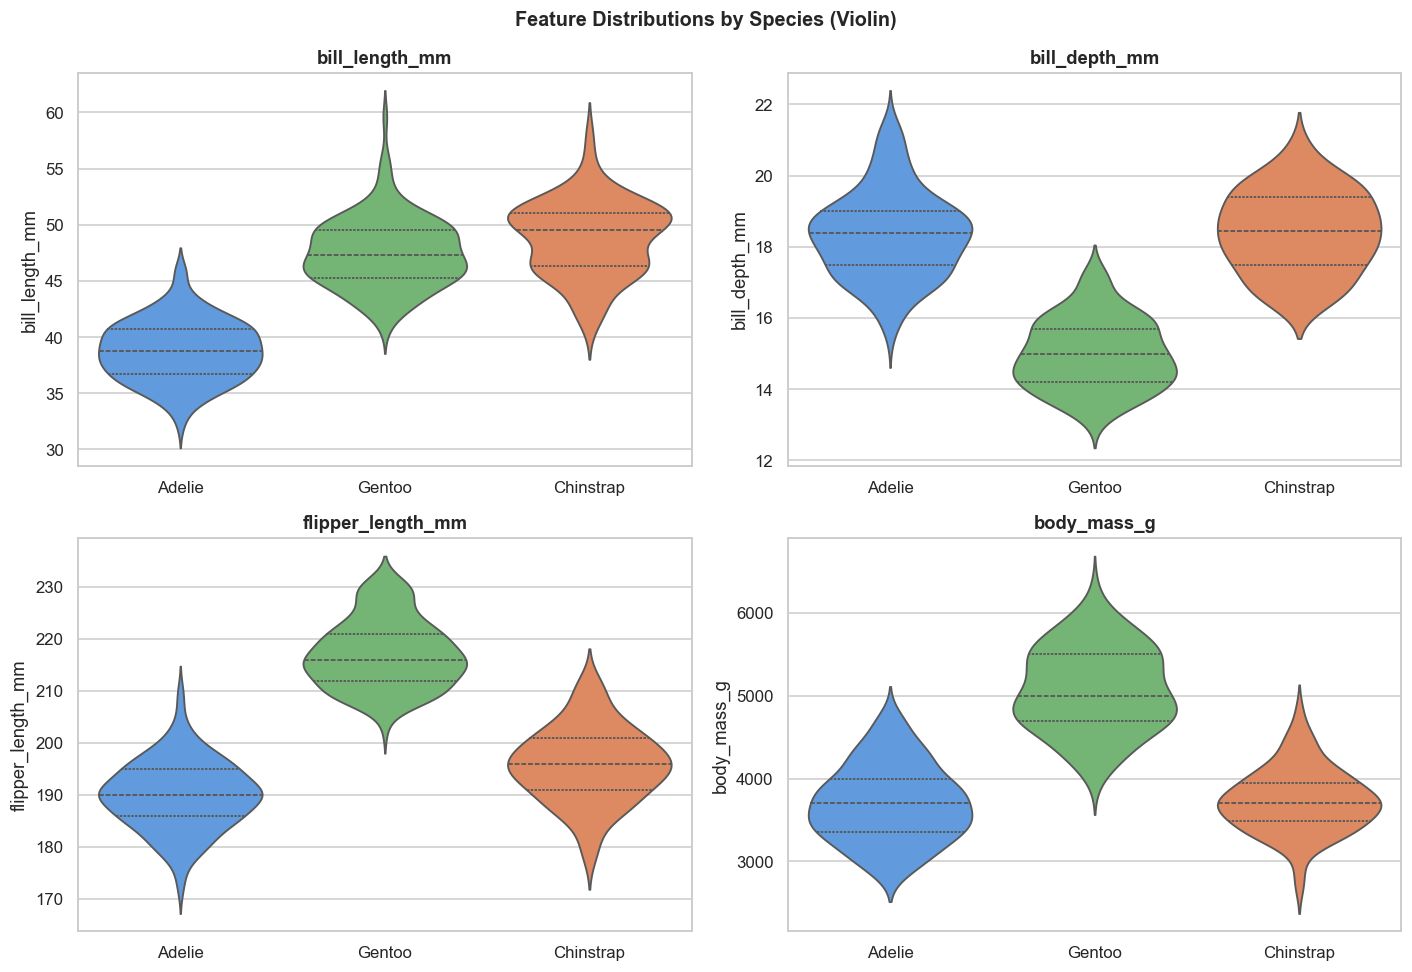

In [79]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
axes = axes.flatten()

for i, col in enumerate(numeric_features):
    sns.violinplot(
        data=df.dropna(subset=[col]),
        x='species', y=col,
        palette=PALETTE,
        inner='quartile',
        ax=axes[i]
    )
    axes[i].set_title(col, fontweight='bold')
    axes[i].set_xlabel('')

plt.suptitle('Feature Distributions by Species (Violin)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

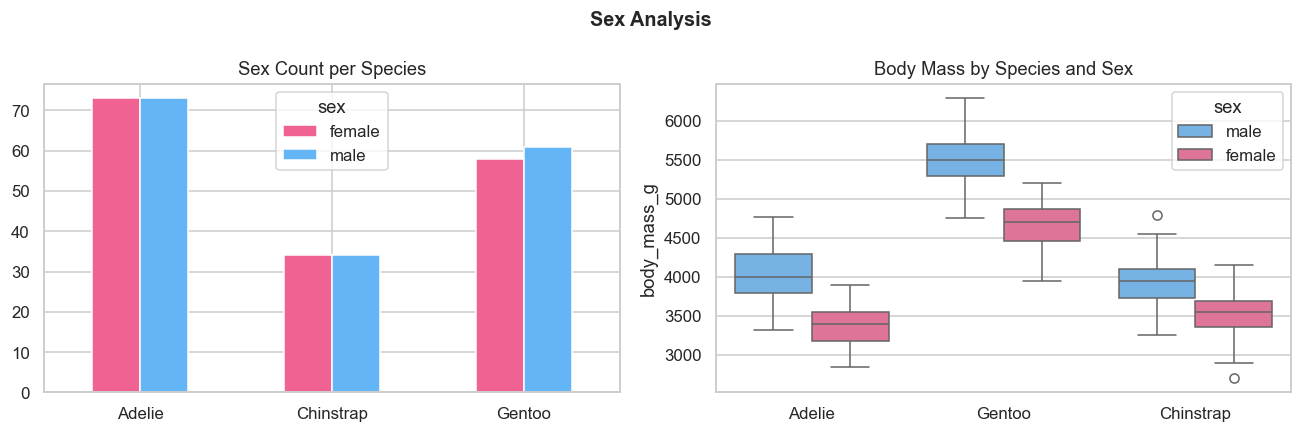

In [80]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Sex ratio per species
sex_species = df.dropna(subset=['sex']).groupby(['species', 'sex']).size().unstack(fill_value=0)
sex_species.plot(kind='bar', ax=axes[0], color=['#f06292', '#64b5f6'], edgecolor='white')
axes[0].set_title('Sex Count per Species')
axes[0].set_xlabel('')
axes[0].tick_params(axis='x', rotation=0)

# Body mass by sex and species
sns.boxplot(
    data=df.dropna(subset=['sex', 'body_mass_g']),
    x='species', y='body_mass_g', hue='sex',
    palette={'male': '#64b5f6', 'female': '#f06292'},
    ax=axes[1]
)
axes[1].set_title('Body Mass by Species and Sex')
axes[1].set_xlabel('')

plt.suptitle('Sex Analysis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

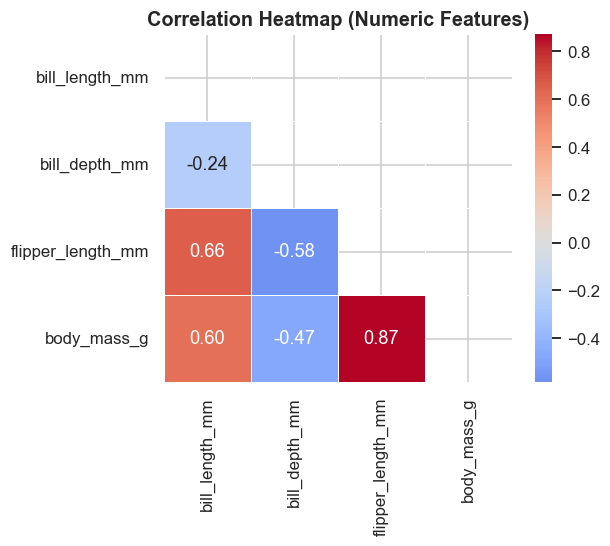

In [81]:
corr = df[numeric_features].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(
    corr, mask=mask, annot=True, fmt='.2f',
    cmap='coolwarm', center=0, ax=ax,
    linewidths=0.5, square=True
)
ax.set_title('Correlation Heatmap (Numeric Features)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

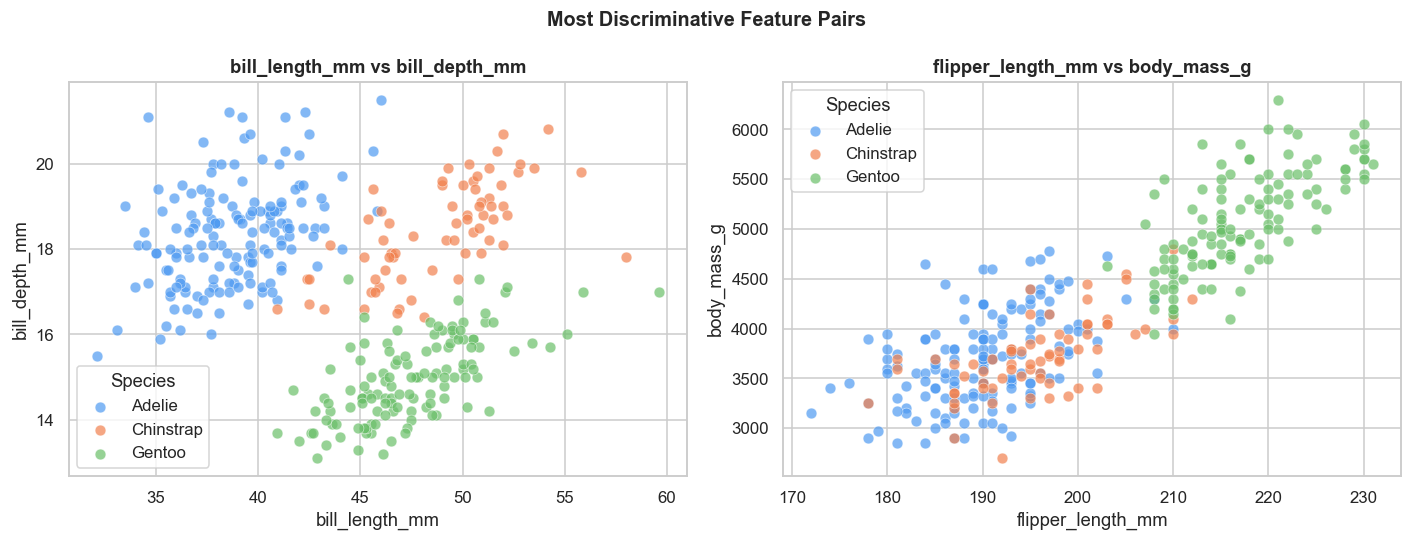

In [82]:
# The two most discriminative feature combinations
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, (xcol, ycol) in zip(axes, [
    ('bill_length_mm', 'bill_depth_mm'),
    ('flipper_length_mm', 'body_mass_g')
]):
    for species, grp in df.dropna(subset=[xcol, ycol]).groupby('species'):
        ax.scatter(grp[xcol], grp[ycol],
                   label=species, color=PALETTE[species],
                   alpha=0.7, edgecolors='white', linewidth=0.4, s=50)
    ax.set_xlabel(xcol)
    ax.set_ylabel(ycol)
    ax.set_title(f'{xcol} vs {ycol}', fontweight='bold')
    ax.legend(title='Species')

plt.suptitle('Most Discriminative Feature Pairs', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 3. Preprocessing

In [83]:
df_clean = df.copy()

# Drop the 2 rows missing physical measurements
df_clean.dropna(subset=['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g'], inplace=True)

# Fill missing sex with mode per species (smarter than global mode)
df_clean['sex'] = df_clean.groupby('species')['sex'].transform(
    lambda x: x.fillna(x.mode()[0])
)

print(f'Rows after cleaning: {len(df_clean)} (dropped {len(df) - len(df_clean)} rows)')
print(f'Remaining nulls: {df_clean.isnull().sum().sum()}')

Rows after cleaning: 342 (dropped 2 rows)
Remaining nulls: 0


In [84]:
df_model = df_clean.copy()

# Encode binary
df_model['sex'] = df_model['sex'].map({'male': 1, 'female': 0})

# One-hot encode island
df_model = pd.get_dummies(df_model, columns=['island'], drop_first=False)

# Encode target
species_map = {'Adelie': 0, 'Chinstrap': 1, 'Gentoo': 2}
df_model['species'] = df_model['species'].map(species_map)

X = df_model.drop(columns=['species'])
y = df_model['species']

print(f'Feature matrix: {X.shape}')
print(f'Features: {list(X.columns)}')

Feature matrix: (342, 8)
Features: ['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g', 'sex', 'island_Biscoe', 'island_Dream', 'island_Torgersen']


In [85]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)
print(f'Train: {X_train.shape} | Test: {X_test.shape}')
print(f'Train class distribution:\n{y_train.value_counts().rename({0:"Adelie",1:"Chinstrap",2:"Gentoo"})}')

Train: (273, 8) | Test: (69, 8)
Train class distribution:
species
Adelie       121
Gentoo        98
Chinstrap     54
Name: count, dtype: int64


## 4. Model Comparison

8 models, **5-fold stratified cross-validation**, same split for all.

Metrics for multiclass:
- **Accuracy** — overall correctness
- **F1 (weighted)** — accounts for class imbalance
- **ROC-AUC (OVR weighted)** — one-vs-rest AUC per class, averaged by support

In [86]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

models = {
    'Baseline (majority)' : DummyClassifier(strategy='most_frequent'),
    'Logistic Regression' : Pipeline([('scaler', StandardScaler()),
                                      ('clf', LogisticRegression(max_iter=1000, random_state=RANDOM_STATE))]),
    'KNN'                 : Pipeline([('scaler', StandardScaler()),
                                      ('clf', KNeighborsClassifier())]),
    'Decision Tree'       : DecisionTreeClassifier(random_state=RANDOM_STATE),
    'Random Forest'       : RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE),
    'Gradient Boosting'   : GradientBoostingClassifier(n_estimators=200, random_state=RANDOM_STATE),
    'XGBoost'             : XGBClassifier(n_estimators=200, random_state=RANDOM_STATE,
                                          eval_metric='mlogloss', num_class=3),
    'LightGBM'            : LGBMClassifier(n_estimators=200, random_state=RANDOM_STATE, verbose=-1)
}

results = []
for name, model in models.items():
    acc = cross_val_score(model, X_train, y_train, cv=cv, scoring='accuracy').mean()
    f1  = cross_val_score(model, X_train, y_train, cv=cv, scoring='f1_weighted').mean()
    auc = cross_val_score(model, X_train, y_train, cv=cv, scoring='roc_auc_ovr_weighted').mean()
    results.append({'Model': name, 'Accuracy': acc, 'F1 (weighted)': f1, 'ROC-AUC (OVR)': auc})
    print(f'{name:25s}  Acc={acc:.3f}  F1={f1:.3f}  AUC={auc:.3f}')

results_df = pd.DataFrame(results).set_index('Model').sort_values('ROC-AUC (OVR)', ascending=False)
print('\nRanked by ROC-AUC:')
results_df.round(3)

Baseline (majority)        Acc=0.443  F1=0.272  AUC=0.500
Logistic Regression        Acc=0.996  F1=0.996  AUC=1.000
KNN                        Acc=0.985  F1=0.985  AUC=1.000
Decision Tree              Acc=0.949  F1=0.948  AUC=0.960
Random Forest              Acc=0.989  F1=0.989  AUC=1.000
Gradient Boosting          Acc=0.978  F1=0.978  AUC=1.000
XGBoost                    Acc=0.978  F1=0.978  AUC=0.999
LightGBM                   Acc=0.989  F1=0.989  AUC=1.000

Ranked by ROC-AUC:


,Accuracy,F1 (weighted),ROC-AUC (OVR)
Model,,,
Logistic Regression,0.996,0.996,1.000
Random Forest,0.989,0.989,1.000
KNN,0.985,0.985,1.000
LightGBM,0.989,0.989,1.000
Gradient Boosting,0.978,0.978,1.000
XGBoost,0.978,0.978,0.999
Decision Tree,0.949,0.948,0.960
Baseline (majority),0.443,0.272,0.500


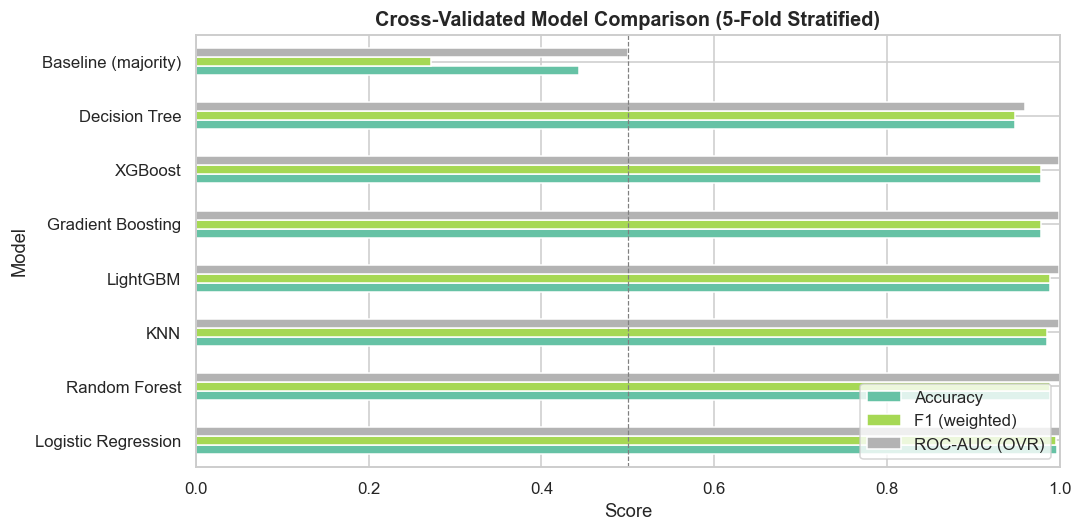

In [87]:
fig, ax = plt.subplots(figsize=(10, 5))
results_df.plot(kind='barh', ax=ax, colormap='Set2', edgecolor='white')
ax.set_xlim(0, 1)
ax.axvline(0.5, color='grey', linestyle='--', linewidth=0.8)
ax.set_title('Cross-Validated Model Comparison (5-Fold Stratified)', fontsize=13, fontweight='bold')
ax.set_xlabel('Score')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

## 5. Hyperparameter Tuning

Tune the best gradient boosting model. Because penguins is a small, clean dataset, we tune both XGBoost and LightGBM and pick the winner.

In [88]:
xgb_grid = {
    'n_estimators' : [100, 200, 300],
    'max_depth'    : [3, 4, 5],
    'learning_rate': [0.05, 0.1, 0.2],
    'subsample'    : [0.8, 1.0]
}

xgb_search = GridSearchCV(
    XGBClassifier(random_state=RANDOM_STATE, eval_metric='mlogloss', num_class=3),
    xgb_grid, cv=cv, scoring='roc_auc_ovr_weighted', n_jobs=-1, verbose=0
)
xgb_search.fit(X_train, y_train)
print(f'XGBoost  best AUC (CV): {xgb_search.best_score_:.4f}')
print(f'Params: {xgb_search.best_params_}')

XGBoost  best AUC (CV): 0.9994
Params: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 200, 'subsample': 0.8}


In [89]:
lgbm_grid = {
    'n_estimators' : [100, 200, 300],
    'max_depth'    : [3, 4, 5],
    'learning_rate': [0.05, 0.1, 0.2],
    'num_leaves'   : [31, 63]
}

lgbm_search = GridSearchCV(
    LGBMClassifier(random_state=RANDOM_STATE, verbose=-1),
    lgbm_grid, cv=cv, scoring='roc_auc_ovr_weighted', n_jobs=-1, verbose=0
)
lgbm_search.fit(X_train, y_train)
print(f'LightGBM best AUC (CV): {lgbm_search.best_score_:.4f}')
print(f'Params: {lgbm_search.best_params_}')

LightGBM best AUC (CV): 0.9996
Params: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 100, 'num_leaves': 31}


In [90]:
if xgb_search.best_score_ >= lgbm_search.best_score_:
    best_model = xgb_search.best_estimator_
    best_name  = 'XGBoost (tuned)'
else:
    best_model = lgbm_search.best_estimator_
    best_name  = 'LightGBM (tuned)'

print(f'Winner: {best_name}')

Winner: LightGBM (tuned)


## 6. Final Evaluation on Hold-Out Test Set

In [91]:
y_pred = best_model.predict(X_test)
y_prob = best_model.predict_proba(X_test)

acc = accuracy_score(y_test, y_pred)
f1  = f1_score(y_test, y_pred, average='weighted')
auc = roc_auc_score(y_test, y_prob, multi_class='ovr', average='weighted')

print(f'=== Final Test Set — {best_name} ===')
print(f'Accuracy      : {acc:.4f}')
print(f'F1 (weighted) : {f1:.4f}')
print(f'ROC-AUC (OVR) : {auc:.4f}')
print()
print(classification_report(y_test, y_pred, target_names=SPECIES))

=== Final Test Set — LightGBM (tuned) ===
Accuracy      : 1.0000
F1 (weighted) : 1.0000
ROC-AUC (OVR) : 1.0000

              precision    recall  f1-score   support

      Adelie       1.00      1.00      1.00        30
   Chinstrap       1.00      1.00      1.00        14
      Gentoo       1.00      1.00      1.00        25

    accuracy                           1.00        69
   macro avg       1.00      1.00      1.00        69
weighted avg       1.00      1.00      1.00        69



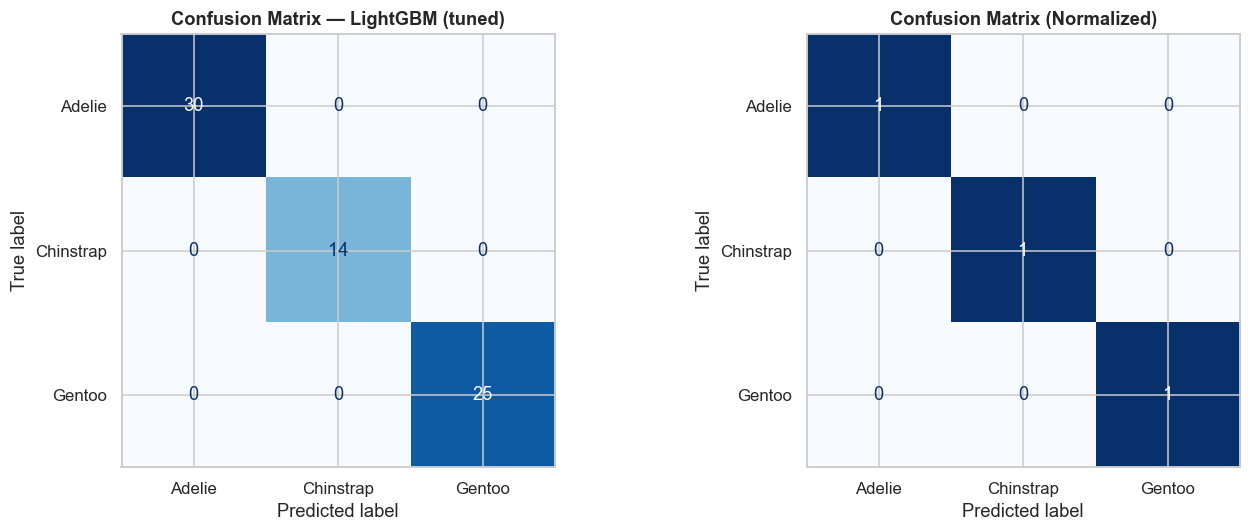

In [92]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=SPECIES)
disp.plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title(f'Confusion Matrix — {best_name}', fontweight='bold')

# Normalized confusion matrix (shows rates, not counts)
cm_norm = confusion_matrix(y_test, y_pred, normalize='true')
disp_norm = ConfusionMatrixDisplay(cm_norm.round(2), display_labels=SPECIES)
disp_norm.plot(ax=axes[1], colorbar=False, cmap='Blues')
axes[1].set_title('Confusion Matrix (Normalized)', fontweight='bold')

plt.tight_layout()
plt.show()

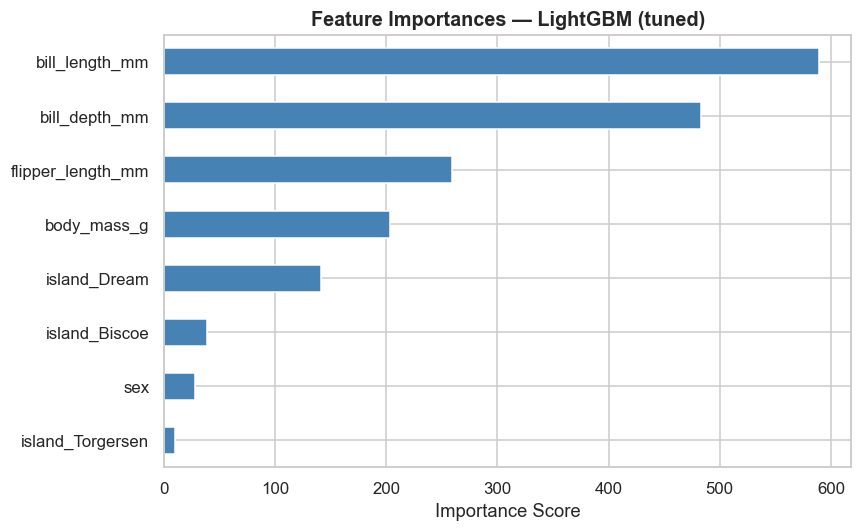

Ranked features:
bill_length_mm       589
bill_depth_mm        483
flipper_length_mm    259
body_mass_g          203
island_Dream         141
island_Biscoe         39
sex                   28
island_Torgersen      10
dtype: int32


In [93]:
feat_imp = pd.Series(best_model.feature_importances_, index=X.columns)
feat_imp = feat_imp.sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 5))
feat_imp.plot(kind='barh', ax=ax, color='steelblue', edgecolor='white')
ax.set_title(f'Feature Importances — {best_name}', fontsize=13, fontweight='bold')
ax.set_xlabel('Importance Score')
plt.tight_layout()
plt.show()

print('Ranked features:')
print(feat_imp.sort_values(ascending=False))

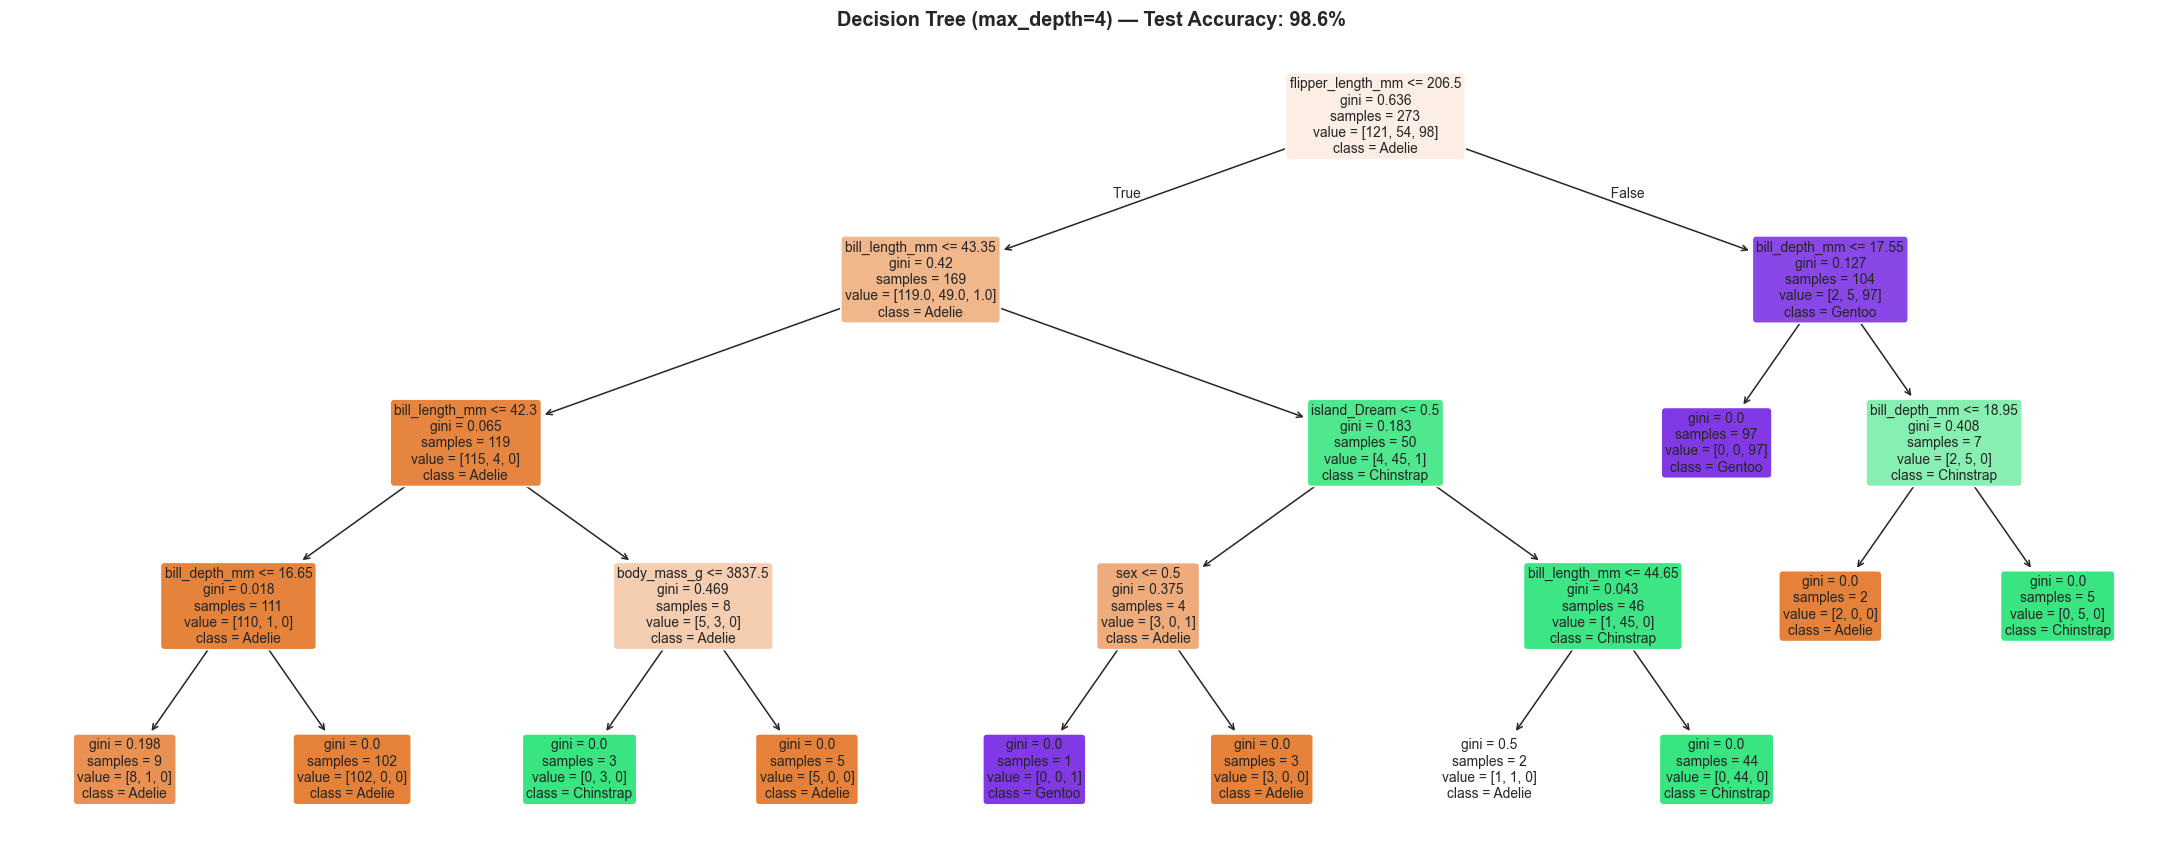

In [94]:
# Decision Tree visualization — useful to understand the decision rules
dt_vis = DecisionTreeClassifier(max_depth=4, random_state=RANDOM_STATE)
dt_vis.fit(X_train, y_train)
dt_acc = accuracy_score(y_test, dt_vis.predict(X_test))

plt.figure(figsize=(20, 8))
plot_tree(
    dt_vis,
    feature_names=list(X.columns),
    class_names=SPECIES,
    filled=True, rounded=True, fontsize=9
)
plt.title(f'Decision Tree (max_depth=4) — Test Accuracy: {dt_acc:.1%}', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 7. Conclusions

### What separates the species?
1. **bill_length_mm + bill_depth_mm** — best pair for separating Adelie from Chinstrap (similar size but very different bill shape)
2. **flipper_length_mm + body_mass_g** — cleanly separates Gentoo (significantly larger than the other two)
3. **island** — informative but redundant with the measurements (Chinstrap only lives on Dream, Gentoo mostly on Biscoe)

### Why accuracy is very high here
The three species are **biologically distinct** enough that even a shallow Decision Tree with 4 splits reaches ~95%+ accuracy. This is expected — penguin species don't overlap much physically. A good data scientist notes this rather than over-crediting the model.

### Key takeaways
- Multiclass classification requires **F1 (weighted)** and **ROC-AUC (OVR)** — accuracy alone hides per-class performance
- The **normalized confusion matrix** reveals which species is hardest to classify (Adelie vs Chinstrap are the closest)
- **Sex imputation per species** (mode per group) is better than global mode — Gentoo have slightly different male/female ratios
- High accuracy on a clean biology dataset is expected — real-world value comes from **understanding why**, not just the score

si flipper_length_mm > 210 → Gentoo
sinon si bill_depth_mm < 18 → Adelie
sinon → Chinstrap